# 1. Data Understanding

Dataset Prediksi Kebutuhan Air Irigasi yang digunakan bersumber dari Kaggle. Dataset ini digunakan untuk mengelompokkan kebutuhan air irigasi berdasarkan variabel yang ada. Karena digunakan untuk mengelompokkan maka target/label yang diprediksi adalah kebutuhan irigasi.

Adapun variabel yang digunakan dalam dataset ini adalah jenis tanah, pH tanah, kelembapan tanah, karbon organik, konduktivitas listrik, suhu, kelembapan udara, curah hujan, lama penyinaran matahari, kecepatan angin, jenis tanaman, tahap pertumbuhan tanaman, musim, jenis irigasi, sumber air, luas lahan, penggunaan mulsa, irigasi sebelumnya, wilayah. Sementara target/label yang digunakan adalah kebutuhan irigasi.

In [7]:
#IMPORT LIBRARY
import pandas as pd

#Pengumpulan Data dan Load Data
data = pd.read_csv("irrigation_prediction.csv")
print (data.head(5))

print("-"*70)
#Menampilkan data info
data.info()

print("-"*70)
#Menampilkan statistik deskriptif kategorikal dan numerik
print (data.describe())

print("-"*70)
print (data.describe(include=['object']))

  Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  \
0      Clay     6.14          36.48            0.42                     2.17   
1      Silt     6.41          50.56            0.38                     0.23   
2     Sandy     7.71          40.07            1.09                     2.18   
3      Clay     5.96          12.75            1.56                     0.40   
4      Clay     7.76          18.58            0.95                     2.52   

   Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  \
0          21.90     31.19      1167.70            4.01            1.97   
1          36.50     26.01       831.28           10.72           16.82   
2          41.83     76.41      1844.45            7.75           19.03   
3          37.22     43.32       306.26            8.90           11.44   
4          22.38     86.44      1875.63           10.39           11.26   

  Crop_Type Crop_Growth_Stage  Season Irrigation_Type Water_Source  

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1652\3166838174.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print (data.describe(include=['object']))


# 2. Data Preprocessing

data null:
 Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64
----------------------------------------------------------------------
duplikat:
 0
----------------------------------------------------------------------


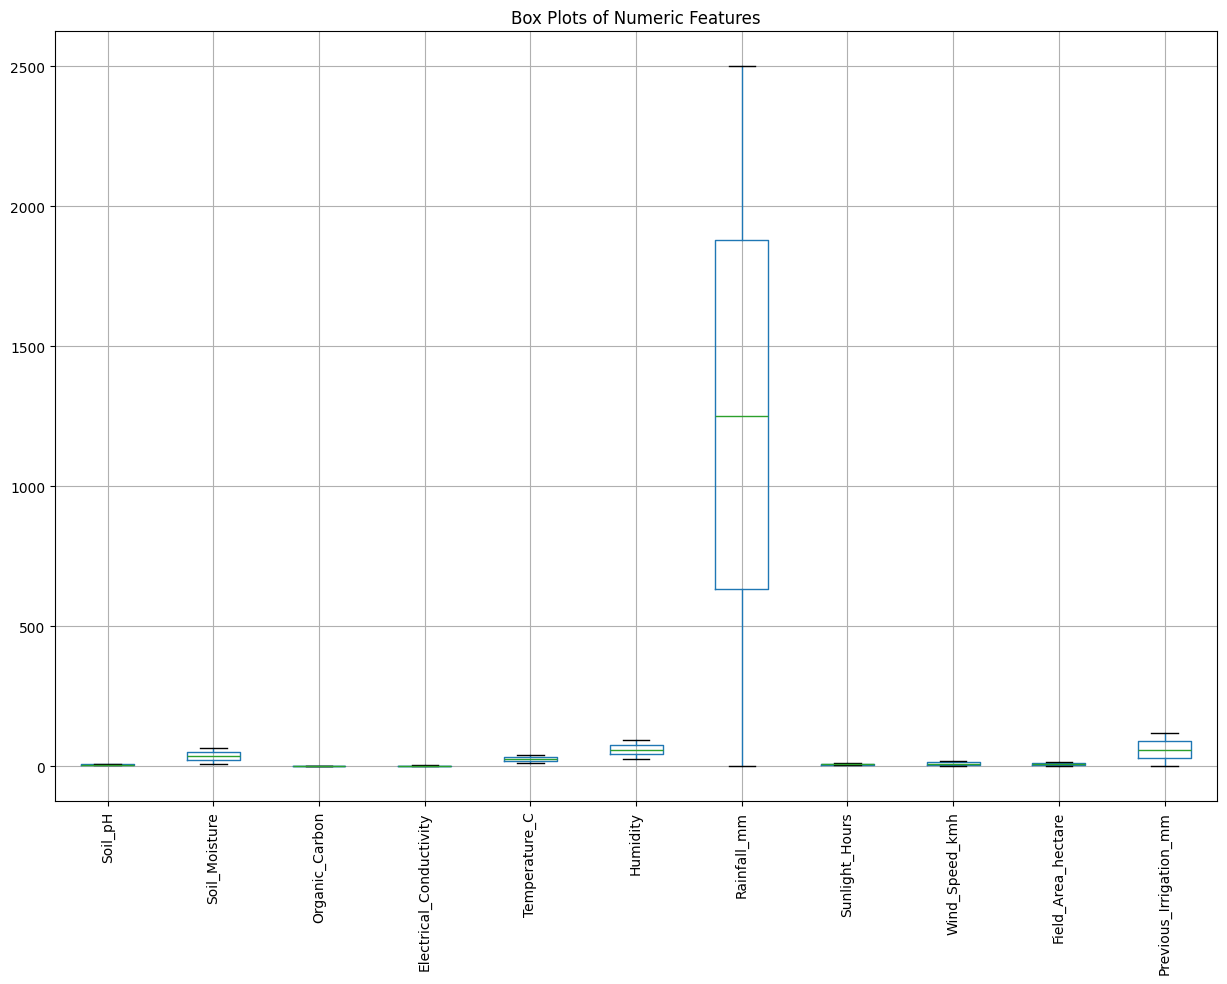

----------------------------------------------------------------------
Jumlah outlier: 0
Empty DataFrame
Columns: [Rainfall_mm]
Index: []
----------------------------------------------------------------------
Data setelah encoding:
   Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  \
0          0     6.14          36.48            0.42                     2.17   
1          3     6.41          50.56            0.38                     0.23   
2          2     7.71          40.07            1.09                     2.18   
3          0     5.96          12.75            1.56                     0.40   
4          0     7.76          18.58            0.95                     2.52   

   Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  \
0          21.90     31.19      1167.70            4.01            1.97   
1          36.50     26.01       831.28           10.72           16.82   
2          41.83     76.41      1844.45            7.75 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1652\1535146190.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = data.select_dtypes(include=['object']).columns


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

#Menampilkan Jumlah Data Null dan Duplikat
print("data null:\n",data.isnull().sum())
print("-"*70)
print("duplikat:\n",data.duplicated().sum())

#Menangani Outlier
print("-"*70)
#Tentukan kolom numerik/ untuk memilih kolom numerik saja
numeric_features = data.select_dtypes(include=['int64', 'float64']).columns

#Lalu buat boxplot/ untuk melihat data, melihat data outlier
plt.figure(figsize=(15, 10))
data[numeric_features].boxplot()
plt.title('Box Plots of Numeric Features')
plt.xticks(rotation=90)
plt.show()

print("-"*70)
#cekoutlier
col = 'Rainfall_mm'

Q1 = data[col].quantile(0.25)
Q3 = data[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data[col] < lower) | (data[col] > upper)]

print("Jumlah outlier:", len(outliers))
print(outliers[['Rainfall_mm']])

print("-"*70)

# Ambil kolom kategorikal
categorical_features = data.select_dtypes(include=['object']).columns

# Label Encoding tiap kolom kategorikal
le = LabelEncoder()
for col in categorical_features:
    data[col] = le.fit_transform(data[col])

print("Data setelah encoding:")
print(data.head())

print("-"*70)

#standarisasi
#Pisahkan Dengan Label
X = data.drop(columns=['Irrigation_Need'])
y = data["Irrigation_Need"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

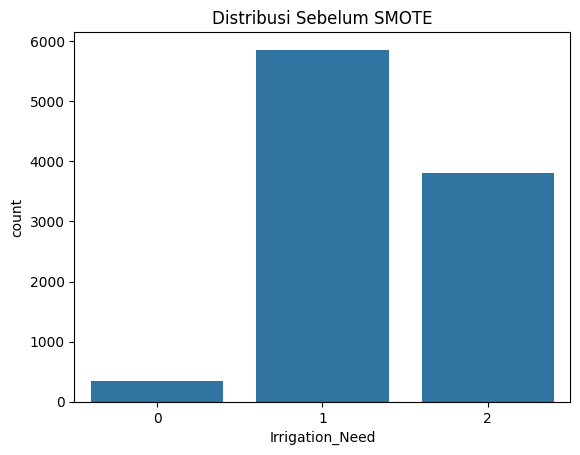

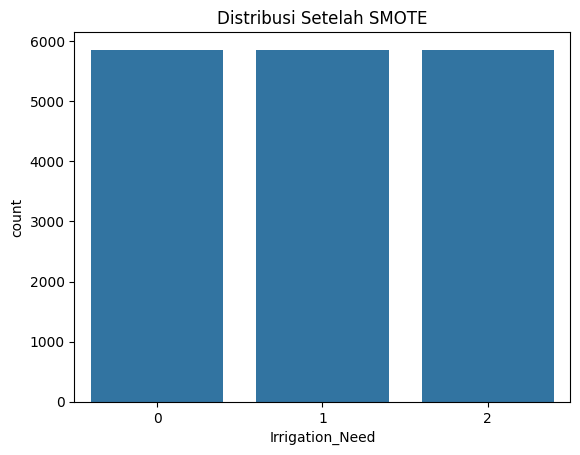

In [9]:
X = data.drop(columns=['Irrigation_Need'])
y = data["Irrigation_Need"]

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

import seaborn as sns

# Sebelum
plt.figure()
sns.countplot(x=y)
plt.title("Distribusi Sebelum SMOTE")
plt.show()

# Sesudah
plt.figure()
sns.countplot(x=y_res)
plt.title("Distribusi Setelah SMOTE")
plt.show()

# 3. EDA

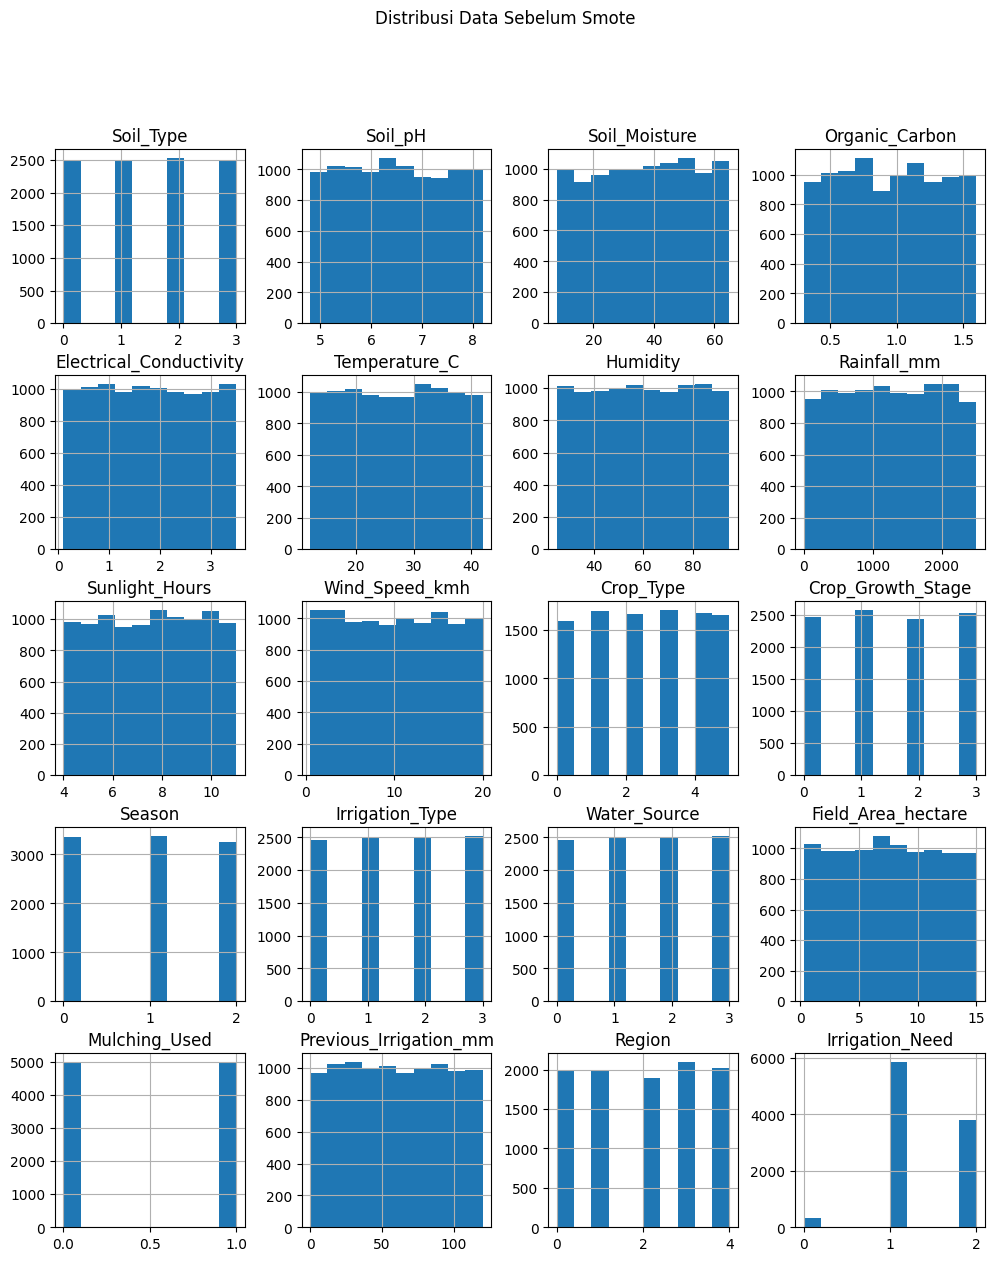

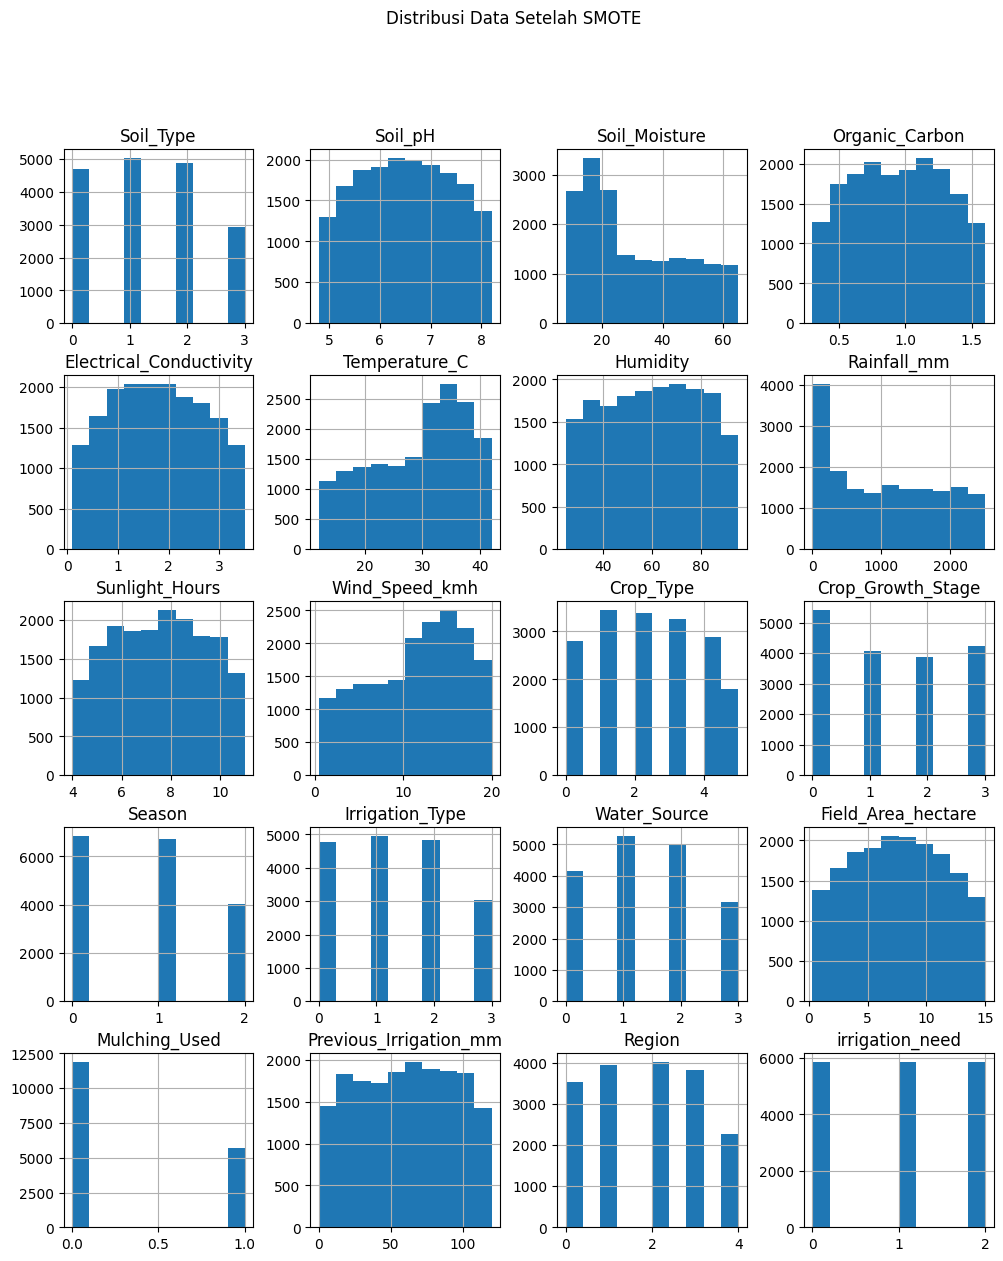

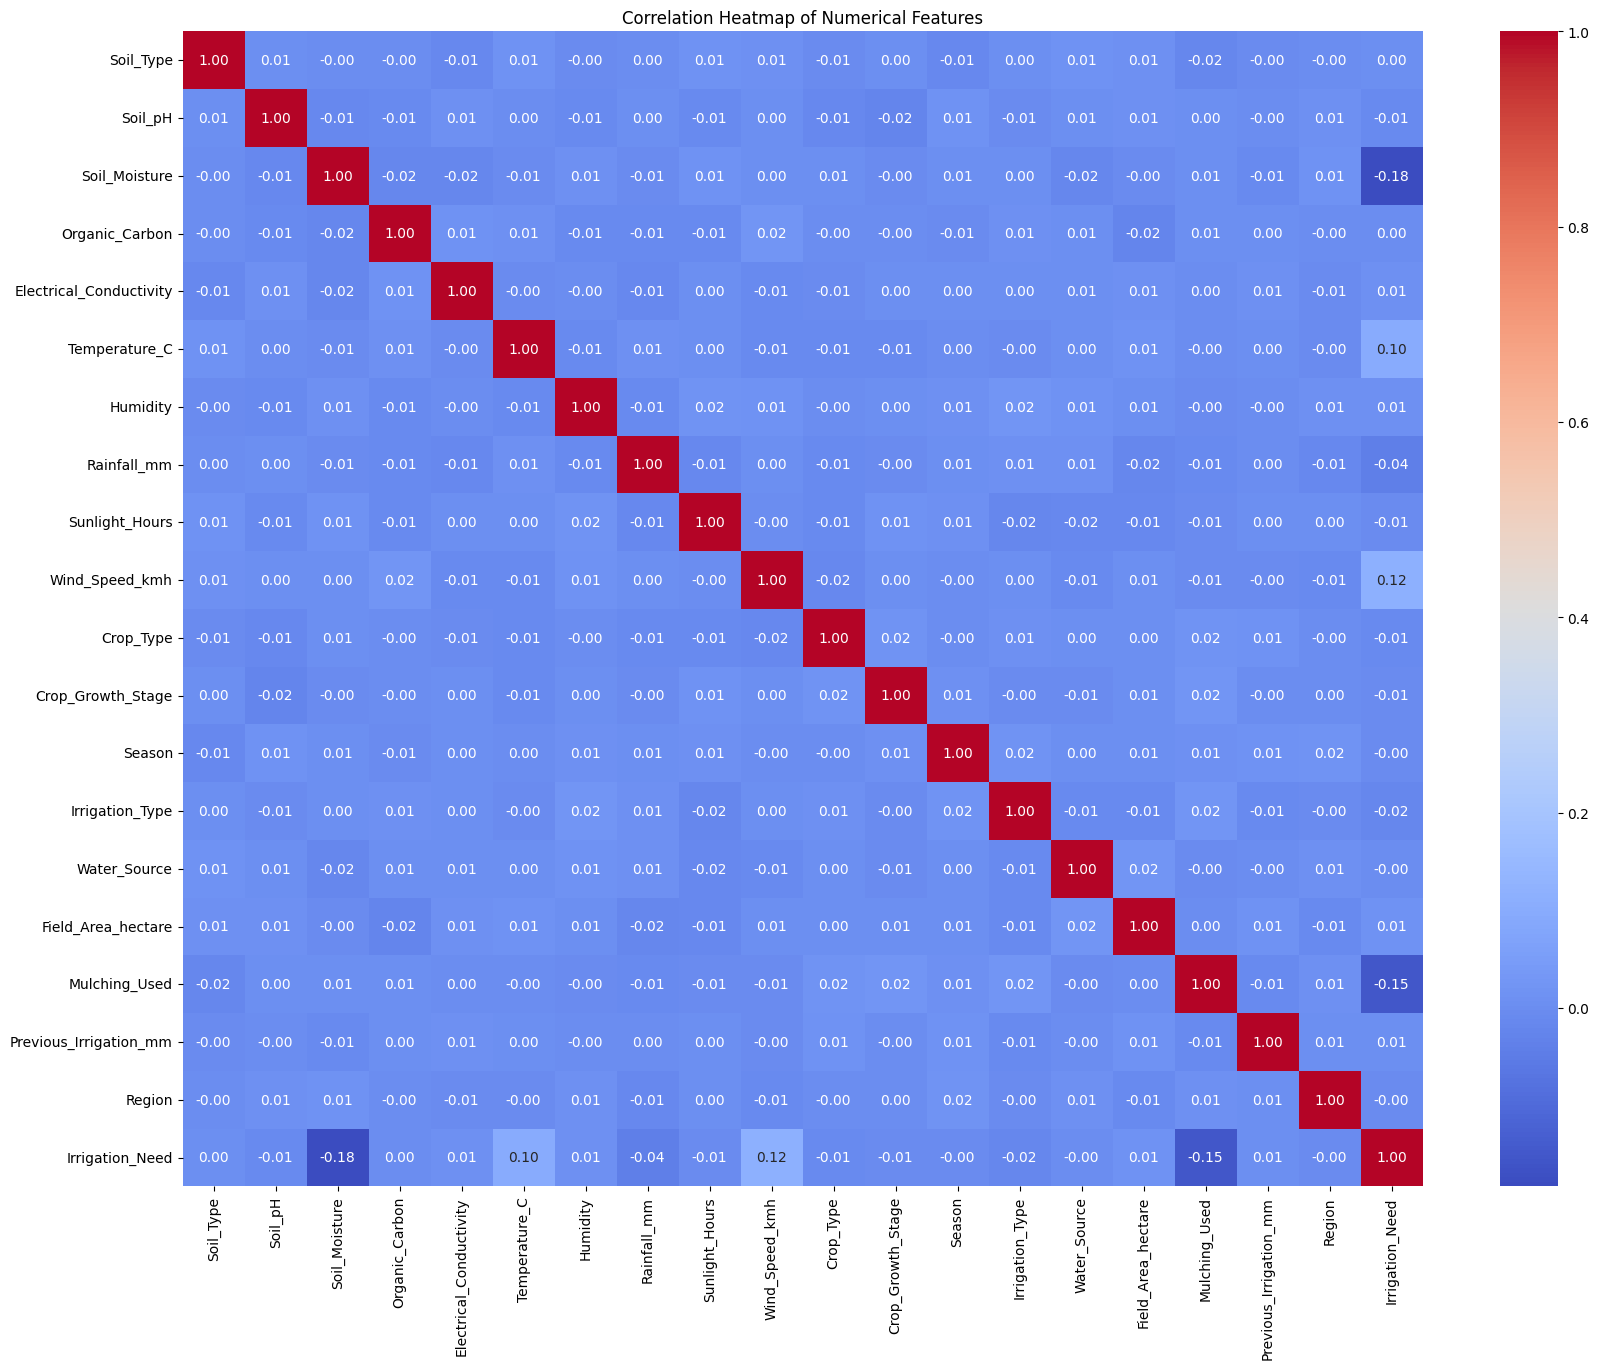

In [10]:
import seaborn as sns
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

#Pisahkan Dengan Label
X = data.drop(columns=['Irrigation_Need'])
y = data["Irrigation_Need"]

#Distribusi Data
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[num_cols].hist(figsize=(12,14))
plt.suptitle("Distribusi Data Sebelum Smote")
plt.show()

#smote
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Gabungkan fitur + label
data_res = pd.concat([pd.DataFrame(X_res, columns=X.columns),
                      pd.Series(y_res, name='irrigation_need')], axis=1)
num_cols = data_res.select_dtypes(include=['int64', 'float64']).columns

data_res[num_cols].hist(figsize=(12,14))
plt.suptitle("Distribusi Data Setelah SMOTE")
plt.show()

# Select only numerical columns for correlation calculation
numerical_data = data.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()

# Plotting the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 4. Data Splitting

In [11]:
from sklearn.model_selection import train_test_split

# 1. Memisahkan Fitur (X) dan Target (y)
# Target kita adalah 'salary', sehingga kolom ini kita pisahkan dari X
X = data.drop(columns=['Irrigation_Need'])
y = data['Irrigation_Need']

# 2. Skenario 1: 70% Training : 30% Testing
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.30, random_state=42)
print("--- Skenario 1 (70% Train : 30% Test) ---")
print(f"Data Training : {X_train_70.shape[0]} baris")
print(f"Data Testing  : {X_test_70.shape[0]} baris\n")

# 3. Skenario 2: 80% Training : 20% Testing
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.20, random_state=42)
print("--- Skenario 2 (80% Train : 20% Test) ---")
print(f"Data Training : {X_train_80.shape[0]} baris")
print(f"Data Testing  : {X_test_80.shape[0]} baris\n")

# 4. Skenario 3: 90% Training : 10% Testing
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(X, y, test_size=0.10, random_state=42)
print("--- Skenario 3 (90% Train : 10% Test) ---")
print(f"Data Training : {X_train_90.shape[0]} baris")
print(f"Data Testing  : {X_test_90.shape[0]} baris")

--- Skenario 1 (70% Train : 30% Test) ---
Data Training : 7000 baris
Data Testing  : 3000 baris

--- Skenario 2 (80% Train : 20% Test) ---
Data Training : 8000 baris
Data Testing  : 2000 baris

--- Skenario 3 (90% Train : 10% Test) ---
Data Training : 9000 baris
Data Testing  : 1000 baris


# Random Forest dan Hyperparameter (70:30)

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 6, 'n_estimators': 200}
----------------------------------------
Akurasi: 0.954
Akurasi Training : 96.69%
Akurasi Testing  : 95.40%
----------------------------------------
Selisih (GAP): 1.29%

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.91      0.66        98
           1       1.00      0.97      0.99      1776
           2       0.95      0.93      0.94      1126

    accuracy                           0.95      3000
   macro avg       0.82      0.94      0.86      3000
weighted avg       0.96      0.95      0.96      3000



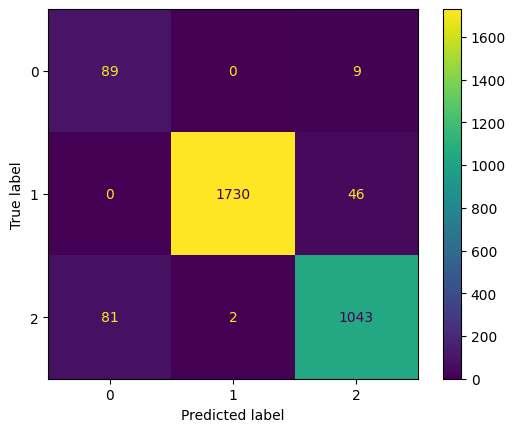

In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

# 2. SMOTE hanya di data training
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Parameter Grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'max_features': [4, 6, 'sqrt'],
    'class_weight': ['balanced']
}

# 4. Model dasar
rf = RandomForestClassifier(random_state=42)

# 5. Grid Search
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring='f1_macro',  # penting untuk multiclass imbalance
    n_jobs=-1
)

# 6. Training pakai data hasil SMOTE
grid.fit(X_train_res, y_train_res)

# 7. Model terbaik
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("-"*40)

# 8. Evaluasi
y_pred = best_model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

# Akurasi training (pakai data hasil SMOTE)
y_train_pred = best_model.predict(X_train_res)
train_acc = accuracy_score(y_train_res, y_train_pred)

# Akurasi testing
test_acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Training : {train_acc:.2%}")
print(f"Akurasi Testing  : {test_acc:.2%}")
print("-"*40)

# GAP
gap = train_acc - test_acc
print(f"Selisih (GAP): {gap:.2%}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# Random Forest dan Hyperparameter 80:20

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 6, 'n_estimators': 100}
----------------------------------------
Akurasi: 0.96
Akurasi Training : 96.48%
Akurasi Testing  : 96.00%
----------------------------------------
Selisih (GAP): 0.48%

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.88      0.67        59
           1       1.00      0.98      0.99      1204
           2       0.96      0.93      0.95       737

    accuracy                           0.96      2000
   macro avg       0.83      0.93      0.87      2000
weighted avg       0.97      0.96      0.96      2000



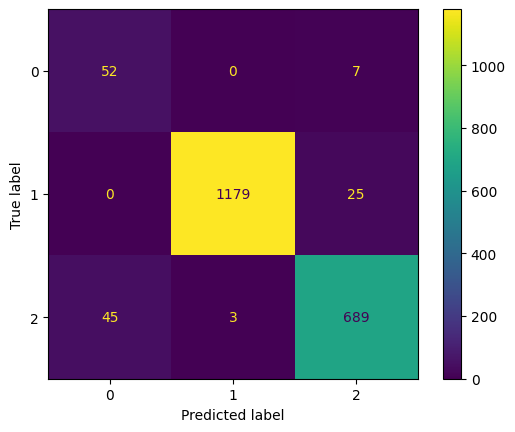

In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 2. SMOTE hanya di data training
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Parameter Grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'max_features': [4, 6, 'sqrt'],
    'class_weight': ['balanced']
}

# 4. Model dasar
rf = RandomForestClassifier(random_state=42)

# 5. Grid Search
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring='f1_macro',  # penting untuk multiclass imbalance
    n_jobs=-1
)

# 6. Training pakai data hasil SMOTE
grid.fit(X_train_res, y_train_res)

# 7. Model terbaik
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("-"*40)

# 8. Evaluasi
y_pred = best_model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

# Akurasi training (pakai data hasil SMOTE)
y_train_pred = best_model.predict(X_train_res)
train_acc = accuracy_score(y_train_res, y_train_pred)

# Akurasi testing
test_acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Training : {train_acc:.2%}")
print(f"Akurasi Testing  : {test_acc:.2%}")
print("-"*40)

# GAP
gap = train_acc - test_acc
print(f"Selisih (GAP): {gap:.2%}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# Random Forest dan Hyperparameter 90:10

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 6, 'n_estimators': 100}
----------------------------------------
Akurasi: 0.96
Akurasi Training : 96.66%
Akurasi Testing  : 96.00%
----------------------------------------
Selisih (GAP): 0.66%

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.87      0.68        30
           1       1.00      0.98      0.99       602
           2       0.95      0.94      0.95       368

    accuracy                           0.96      1000
   macro avg       0.84      0.93      0.87      1000
weighted avg       0.97      0.96      0.96      1000



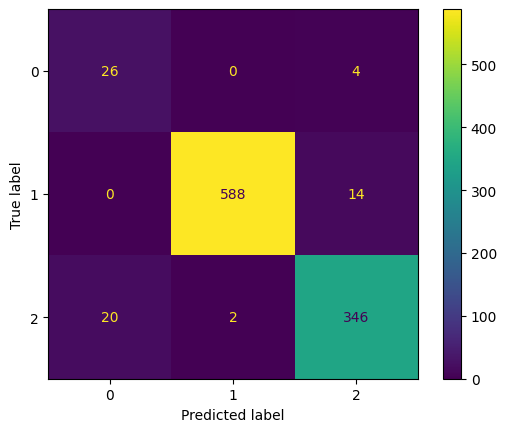

In [14]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, shuffle=True
)

# 2. SMOTE hanya di data training
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Parameter Grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'max_features': [4, 6, 'sqrt'],
    'class_weight': ['balanced']
}

# 4. Model dasar
rf = RandomForestClassifier(random_state=42)

# 5. Grid Search
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring='f1_macro',  # penting untuk multiclass imbalance
    n_jobs=-1
)

# 6. Training pakai data hasil SMOTE
grid.fit(X_train_res, y_train_res)

# 7. Model terbaik
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("-"*40)

# 8. Evaluasi
y_pred = best_model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

# Akurasi training (pakai data hasil SMOTE)
y_train_pred = best_model.predict(X_train_res)
train_acc = accuracy_score(y_train_res, y_train_pred)

# Akurasi testing
test_acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Training : {train_acc:.2%}")
print(f"Akurasi Testing  : {test_acc:.2%}")
print("-"*40)

# GAP
gap = train_acc - test_acc
print(f"Selisih (GAP): {gap:.2%}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# Decision Tree dan Hyperparameter 70:30

Best Parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10}
----------------------------------------
Akurasi: 0.8523333333333334
Akurasi Training : 95.03%
Akurasi Testing  : 85.23%
----------------------------------------
Selisih (GAP): 9.80%

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.65      0.56        98
           1       0.92      0.89      0.90      1776
           2       0.80      0.82      0.81      1126

    accuracy                           0.85      3000
   macro avg       0.74      0.79      0.76      3000
weighted avg       0.86      0.85      0.85      3000



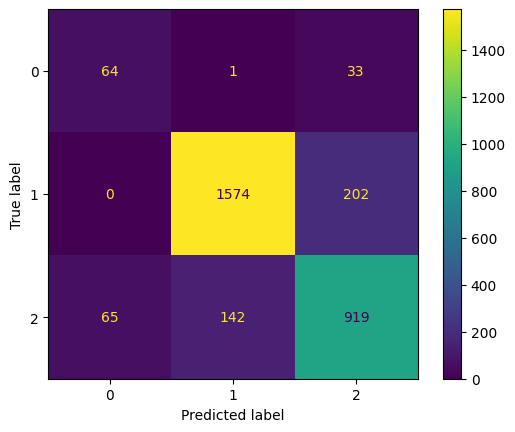

In [15]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

# 2. SMOTE hanya di data training
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Parameter Grid (khusus Decision Tree)
param_grid = {
    'criterion': ['entropy'],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}

# 4. Model dasar
dt = DecisionTreeClassifier(random_state=42)

# 5. Grid Search
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

# 6. Training pakai data hasil SMOTE
grid.fit(X_train_res, y_train_res)

# 7. Model terbaik
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("-"*40)

# 8. Evaluasi
y_pred = best_model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

# Akurasi training (pakai data hasil SMOTE)
y_train_pred = best_model.predict(X_train_res)
train_acc = accuracy_score(y_train_res, y_train_pred)

# Akurasi testing
test_acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Training : {train_acc:.2%}")
print(f"Akurasi Testing  : {test_acc:.2%}")
print("-"*40)

# GAP
gap = train_acc - test_acc
print(f"Selisih (GAP): {gap:.2%}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# Decision Tree dan Hyperparameter 80:20

Best Parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 8}
----------------------------------------
Akurasi: 0.865
Akurasi Training : 94.37%
Akurasi Testing  : 86.50%
----------------------------------------
Selisih (GAP): 7.87%

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.68      0.53        59
           1       0.92      0.91      0.92      1204
           2       0.82      0.81      0.82       737

    accuracy                           0.86      2000
   macro avg       0.73      0.80      0.75      2000
weighted avg       0.87      0.86      0.87      2000



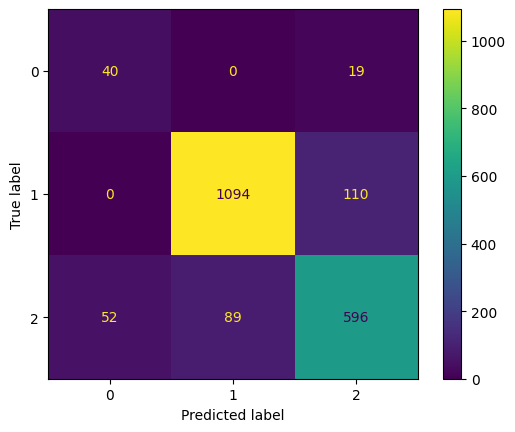

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 2. SMOTE hanya di data training
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Parameter Grid (khusus Decision Tree)
param_grid = {
    'criterion': ['entropy'],
    'max_depth': [5, 10, 15],
    'min_samples_split': [8, 10, 14],
    'min_samples_leaf': [6, 12, 12],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}

# 4. Model dasar
dt = DecisionTreeClassifier(random_state=42)

# 5. Grid Search
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# 6. Training pakai data hasil SMOTE
grid.fit(X_train_res, y_train_res)

# 7. Model terbaik
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("-"*40)

# 8. Evaluasi
y_pred = best_model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

# Akurasi training (pakai data hasil SMOTE)
y_train_pred = best_model.predict(X_train_res)
train_acc = accuracy_score(y_train_res, y_train_pred)

# Akurasi testing
test_acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Training : {train_acc:.2%}")
print(f"Akurasi Testing  : {test_acc:.2%}")
print("-"*40)

# GAP
gap = train_acc - test_acc
print(f"Selisih (GAP): {gap:.2%}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

Decision Tree dan Hyperparameter 90:10

Best Parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 8}
----------------------------------------
Akurasi: 0.872
Akurasi Training : 93.23%
Akurasi Testing  : 87.20%
----------------------------------------
Selisih (GAP): 6.03%

Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.63      0.48        30
           1       0.93      0.91      0.92       602
           2       0.84      0.82      0.83       368

    accuracy                           0.87      1000
   macro avg       0.72      0.79      0.74      1000
weighted avg       0.88      0.87      0.88      1000



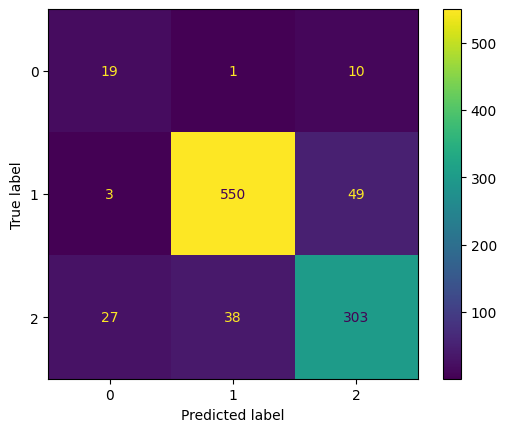

In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, shuffle=True
)

# 2. SMOTE hanya di data training
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Parameter Grid (khusus Decision Tree)
param_grid = {
    'criterion': ['entropy'],
    'max_depth': [5, 10, 15],
    'min_samples_split': [8, 10, 14],
    'min_samples_leaf': [6, 12, 12],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}

# 4. Model dasar
dt = DecisionTreeClassifier(random_state=42)

# 5. Grid Search
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=4,
    scoring='f1_macro',
    n_jobs=-1
)

# 6. Training pakai data hasil SMOTE
grid.fit(X_train_res, y_train_res)

# 7. Model terbaik
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("-"*40)

# 8. Evaluasi
y_pred = best_model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

# Akurasi training (pakai data hasil SMOTE)
y_train_pred = best_model.predict(X_train_res)
train_acc = accuracy_score(y_train_res, y_train_pred)

# Akurasi testing
test_acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Training : {train_acc:.2%}")
print(f"Akurasi Testing  : {test_acc:.2%}")
print("-"*40)

# GAP
gap = train_acc - test_acc
print(f"Selisih (GAP): {gap:.2%}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# Gradient Boosting dan Hyperparameter 70:30

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
----------------------------------------
Akurasi: 0.9646666666666667
Akurasi Training : 99.58%
Akurasi Testing  : 96.47%
----------------------------------------
Selisih (GAP): 3.11%

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.79      0.70        98
           1       1.00      0.98      0.99      1776
           2       0.95      0.96      0.95      1126

    accuracy                           0.96      3000
   macro avg       0.86      0.91      0.88      3000
weighted avg       0.97      0.96      0.97      3000



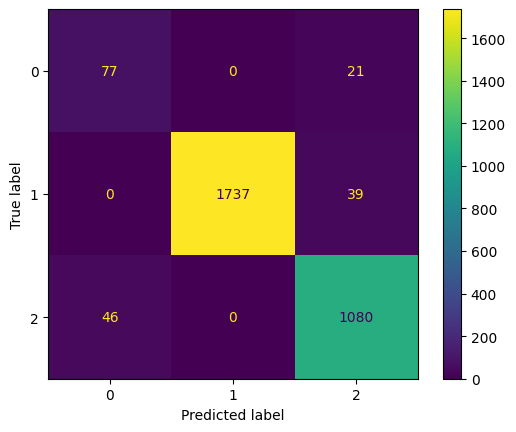

In [18]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

# 2. SMOTE hanya di data training
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Parameter Grid (khusus Gradient Boosting)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}

# 4. Model dasar
gb = GradientBoostingClassifier(random_state=42)

# 5. Grid Search
grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=2,
    scoring='f1_macro',
    n_jobs=-1
)

# 6. Training pakai data hasil SMOTE
grid.fit(X_train_res, y_train_res)

# 7. Model terbaik
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("-"*40)

# 8. Evaluasi
y_pred = best_model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

# Akurasi training (pakai data hasil SMOTE)
y_train_pred = best_model.predict(X_train_res)
train_acc = accuracy_score(y_train_res, y_train_pred)

# Akurasi testing
test_acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Training : {train_acc:.2%}")
print(f"Akurasi Testing  : {test_acc:.2%}")
print("-"*40)

# GAP
gap = train_acc - test_acc
print(f"Selisih (GAP): {gap:.2%}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# Gradient Boosting dan Hyperparameter 80:20

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
----------------------------------------
Akurasi: 0.9655
Akurasi Training : 99.38%
Akurasi Testing  : 96.55%
----------------------------------------
Selisih (GAP): 2.83%

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.80      0.71        59
           1       1.00      0.98      0.99      1204
           2       0.95      0.96      0.95       737

    accuracy                           0.97      2000
   macro avg       0.86      0.91      0.88      2000
weighted avg       0.97      0.97      0.97      2000



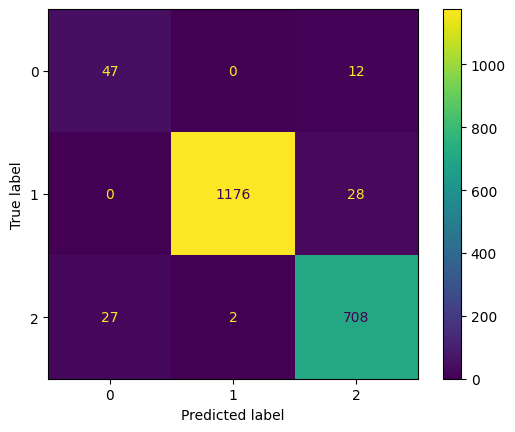

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 2. SMOTE hanya di data training
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Parameter Grid (khusus Gradient Boosting)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}

# 4. Model dasar
gb = GradientBoostingClassifier(random_state=42)

# 5. Grid Search
grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=2,
    scoring='f1_macro',
    n_jobs=-1
)

# 6. Training pakai data hasil SMOTE
grid.fit(X_train_res, y_train_res)

# 7. Model terbaik
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("-"*40)

# 8. Evaluasi
y_pred = best_model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

# Akurasi training (pakai data hasil SMOTE)
y_train_pred = best_model.predict(X_train_res)
train_acc = accuracy_score(y_train_res, y_train_pred)

# Akurasi testing
test_acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Training : {train_acc:.2%}")
print(f"Akurasi Testing  : {test_acc:.2%}")
print("-"*40)

# GAP
gap = train_acc - test_acc
print(f"Selisih (GAP): {gap:.2%}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# Gradient Boosting dan Hyperparameter 90:10

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}
----------------------------------------
Akurasi: 0.976
Akurasi Training : 99.02%
Akurasi Testing  : 97.60%
----------------------------------------
Selisih (GAP): 1.42%

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.80      0.76        30
           1       1.00      0.99      0.99       602
           2       0.96      0.97      0.97       368

    accuracy                           0.98      1000
   macro avg       0.90      0.92      0.91      1000
weighted avg       0.98      0.98      0.98      1000



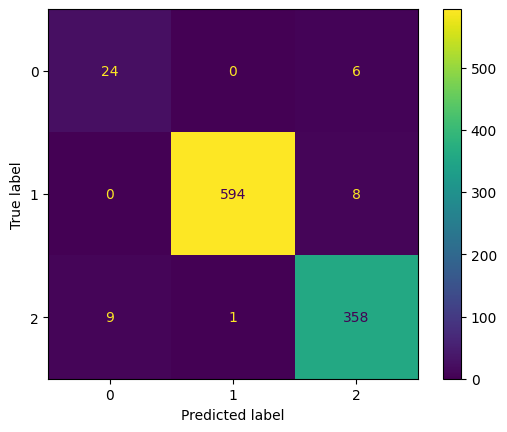

In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, shuffle=True
)

# 2. SMOTE hanya di data training
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Parameter Grid (khusus Gradient Boosting)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}

# 4. Model dasar
gb = GradientBoostingClassifier(random_state=42)

# 5. Grid Search
grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=2,
    scoring='f1_macro',
    n_jobs=-1
)

# 6. Training pakai data hasil SMOTE
grid.fit(X_train_res, y_train_res)

# 7. Model terbaik
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("-"*40)

# 8. Evaluasi
y_pred = best_model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))

# Akurasi training (pakai data hasil SMOTE)
y_train_pred = best_model.predict(X_train_res)
train_acc = accuracy_score(y_train_res, y_train_pred)

# Akurasi testing
test_acc = accuracy_score(y_test, y_pred)

print(f"Akurasi Training : {train_acc:.2%}")
print(f"Akurasi Testing  : {test_acc:.2%}")
print("-"*40)

# GAP
gap = train_acc - test_acc
print(f"Selisih (GAP): {gap:.2%}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# Model Evaluation

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

# 1. Split data (sesuai kode awal kamu)
data_splits = {
    "70% Train : 30% Test": train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True),
    "80% Train : 20% Test": train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True),
    "90% Train : 10% Test": train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)
}

hasil_evaluasi = []

# 2. Parameter (dari kode kamu sebelumnya)
rf_param = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'max_features': [4, 6, 'sqrt'],
    'class_weight': ['balanced']
}

dt_param = {
    'criterion': ['entropy'],
    'max_depth': [10, 15, 20],
    'min_samples_split': [12, 16, 18],
    'min_samples_leaf': [10, 12, 14],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}

gb_param = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}

# 3. Loop semua split
for split_name, (X_tr, X_te, y_tr, y_te) in data_splits.items():

    # SMOTE (sesuai kode awal)
    smote = SMOTE(random_state=42)
    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

    models = {
        "Random Forest": (RandomForestClassifier(random_state=42), rf_param),
        "Decision Tree": (DecisionTreeClassifier(random_state=42), dt_param),
        "Gradient Boosting": (GradientBoostingClassifier(random_state=42), gb_param)
    }

    for model_name, (model, param_grid) in models.items():

        # GridSearch
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=5,
            scoring='f1_macro',
            n_jobs=-1
        )

        grid.fit(X_tr_res, y_tr_res)
        best_model = grid.best_estimator_

        # Prediksi
        y_pred = best_model.predict(X_te)

        # Hitung metrik (classification)
        acc = accuracy_score(y_te, y_pred)
        precision = precision_score(y_te, y_pred, average='weighted')
        recall = recall_score(y_te, y_pred, average='weighted')
        f1 = f1_score(y_te, y_pred, average='weighted')

        # Simpan hasil
        hasil_evaluasi.append({
            "Rasio Data": split_name,
            "Algoritma": model_name,
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        })

# 4. DataFrame hasil
df_eval = pd.DataFrame(hasil_evaluasi)

print("=========================================================")
print("      TABEL KESIMPULAN EVALUASI MODEL (CLASSIFICATION)   ")
print("=========================================================\n")

display(df_eval)

      TABEL KESIMPULAN EVALUASI MODEL (CLASSIFICATION)   



,Rasio Data,Algoritma,Accuracy,Precision,Recall,F1-Score
0,70% Train : 30% Test,Random Forest,0.954000,0.964951,0.954000,0.957640
1,70% Train : 30% Test,Decision Tree,0.836000,0.846283,0.836000,0.839251
2,70% Train : 30% Test,Gradient Boosting,0.963667,0.967123,0.963667,0.965012
3,80% Train : 20% Test,Random Forest,0.963000,0.971081,0.963000,0.965748
4,80% Train : 20% Test,Decision Tree,0.812000,0.822334,0.812000,0.815628
5,80% Train : 20% Test,Gradient Boosting,0.969000,0.971382,0.969000,0.969906
6,90% Train : 10% Test,Random Forest,0.964000,0.970139,0.964000,0.966142
7,90% Train : 10% Test,Decision Tree,0.783000,0.810533,0.783000,0.794305
8,90% Train : 10% Test,Gradient Boosting,0.977000,0.978282,0.977000,0.977526


# Model Comparison

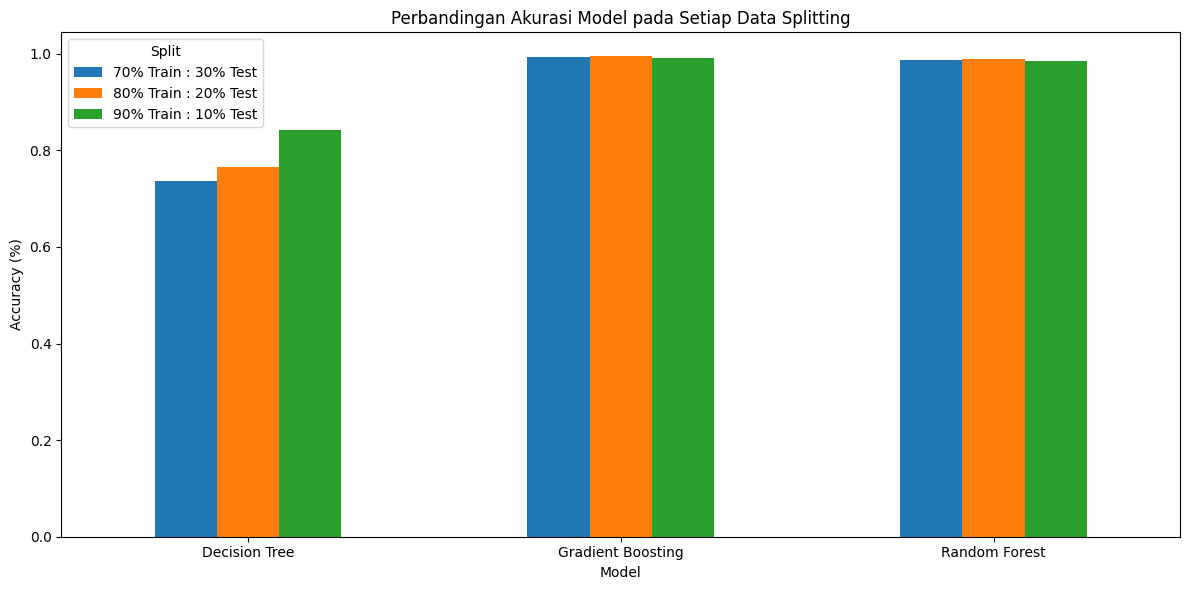

In [29]:
import matplotlib.pyplot as plt

pivot_table = df_eval.pivot_table(index='Algoritma', columns='Rasio Data', values='Accuracy')

pivot_table.plot(kind='bar', figsize=(12, 6))

plt.title('Perbandingan Akurasi Model pada Setiap Data Splitting')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')

plt.xticks(rotation=0)
plt.legend(title='Split')
plt.tight_layout()
plt.show()